In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import bosporus
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

In [3]:
edge_list = pd.read_csv("../SNAP_data/loc-brightkite_edges.txt", delimiter="\t", header=None).values

In [4]:
logs = pd.read_csv("../SNAP_data/loc-brightkite_totalCheckins.txt", delimiter="\t", header=None)

In [5]:
logs.columns = ["user", "check-in time", "latitude", "longitude", "location id"]

In [6]:
def approx_median_location(group):
    coords = group[['latitude', 'longitude']].to_numpy()
    centroid = coords.mean(axis=0)
    dists = np.sum((coords - centroid) ** 2, axis=1)  # squared distance is enough
    return group.iloc[dists.argmin()]

median_locations = logs.groupby('user', group_keys=False).apply(approx_median_location).drop("user", axis=1)

/tmp/ipykernel_3996325/3537444814.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  median_locations = logs.groupby('user', group_keys=False).apply(approx_median_location).drop("user", axis=1)


In [10]:
median_locations = median_locations.drop(["check-in time", "location id"], axis=1)

In [12]:
gdf = gpd.GeoDataFrame(
    median_locations,
    geometry=gpd.points_from_xy(median_locations.longitude, median_locations.latitude),
    crs="EPSG:4326"
)

<Axes: >

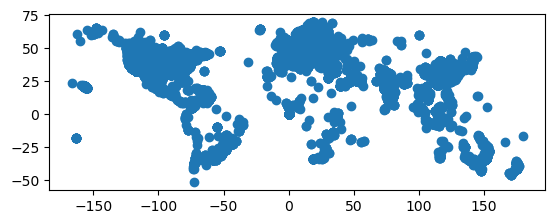

In [13]:
gdf.plot()

In [ ]:


# Query for cities in the US with population > 100k
features = ox.features_from_place(
    "United States",
    tags={'place': 'city', 'population': True}
)
cities_gdf = gpd.GeoDataFrame(features)
cities_gdf['population'] = pd.to_numeric(cities_gdf['population'], errors='coerce')
large_cities = cities_gdf[cities_gdf['population'] > 100000].copy()

# Project to same CRS as gdf
gdf_usa = gdf.to_crs(3857)
large_cities_proj = large_cities.to_crs(3857)

# Calculate distance to nearest city > 100k
gdf_usa['dist_to_nearest_100k_city'] = gdf_usa.geometry.apply(
    lambda geom: large_cities_proj.geometry.distance(geom).min()
)

/data/bionets/je30bery/conda/envs/bosporus/lib/python3.10/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 126,958 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [ ]:
texas = ox.geocode_to_gdf("Texas")
gdf_texas = gpd.sjoin(gdf, texas, predicate="within")

# Query for cities in Texas with population > 100k
texas_features = ox.features_from_place(
    "Texas",
    tags={'place': 'city', 'population': True}
)
texas_cities_gdf = gpd.GeoDataFrame(texas_features)
texas_cities_gdf['population'] = pd.to_numeric(texas_cities_gdf['population'], errors='coerce')
large_texas_cities = texas_cities_gdf[texas_cities_gdf['population'] > 100000].copy()

# Project to same CRS
texas_proj = texas.to_crs(3857)
gdf_texas_proj = gdf_texas.to_crs(3857)
large_texas_cities_proj = large_texas_cities.to_crs(3857)

# Calculate distance to nearest city > 100k in Texas
gdf_texas_proj['dist_to_nearest_100k_city'] = gdf_texas_proj.geometry.apply(
    lambda geom: large_texas_cities_proj.geometry.distance(geom).min()
)

In [ ]:
gdf_texas.plot(markersize=5, c=gdf_texas_proj["dist_to_nearest_100k_city"], figsize=(20, 5))
plt.show()

In [ ]:
measures = ["degree", "closeness", "pagerank", "clustering"]
bf = bosporus.BosporusFlow()
bf.set_edge_list(edge_list)
bf.set_custom_distances(gdf_usa['dist_to_nearest_100k_city'])
bf.compute_centralities(measures=measures)
bf.fit_models(measures=measures, distance_key="dist_to_nearest_100k_city")

In [ ]:
G = nx.from_edgelist(edge_list)

In [ ]:
users = list(G.nodes).copy()
removed_users = list()
for n in users:
    try:
        G.nodes[n]["pos"] = median_locations.loc[n][["latitude", "longitude"]].values[::-1]
    except:
        G.remove_node(n)
        removed_users.append(n)